In [2]:
#Data handling
import pandas as pd
import numpy as np
from datetime import datetime
import missingno as msno

#Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency #compared some categories during eda

# Survival package
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.util import Surv #needed for dual ys
from sksurv.preprocessing import OneHotEncoder #cant use sklearn OHE for surv packages
#models
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.tree import SurvivalTree
from sksurv.ensemble import RandomSurvivalForest
#scoring
from sksurv.metrics import concordance_index_censored 

# Generall modelling tools
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.model_selection import train_test_split


# Source - https://stackoverflow.com/a/79357278
# Posted by gndps
# Retrieved 2026-02-14, License - CC BY-SA 4.0
# View all of df
pd.set_option("display.max_rows", None, "display.max_columns", None)

# Lets see if we get the question this time?
np.random.seed(42)
RANDOM_STATE=42

In [3]:
df=pd.read_csv("fully_merged_anon.csv")
df.head()

,most_recent_visit,active,created,birth_y_m,age,most_recent_y,most_recent_m,most_recent_d,total_ltv_inc,total_ltv_ex,product,days_since_last_pay,subscription_duration_days,total_cancellations,total_entries,cancellation_date,n_quits,check_in,theoretical_inactive_date,anon_id
0,2025-11-28 10:28:00,yes,1990-01-01,1977-09-01,49.0,2025,11,28,22193.0,20936.72,crossfit_12_mån_autogiro_open_gym,13.0,762.0,12.0,502.0,2026-01-21,3.0,502.0,2026-02-26,3a961561-9943-4b71-a29e-35276e9b10f7
1,2023-09-04 18:09:00,no,1990-01-01,1977-03-01,49.0,2023,9,4,22561.0,21283.98,crossfit_6_mån_autogiro_fullt_medlemskap,897.0,822.0,81.0,169.0,2023-08-22,1.0,169.0,2023-08-26,64809e17-4f02-441b-8357-40d9ae116ff9
2,2022-04-23 12:02:00,no,1990-01-01,1993-02-01,33.0,2022,4,23,9438.0,8903.73,crossfit_12_mån_autogiro_open_gym,1385.0,334.0,NaN,75.0,2022-04-15,2.0,75.0,2022-05-27,b0e8d0a1-c0c4-41d8-ac42-3c487134bae4
3,2025-03-24 18:10:00,yes,1990-01-01,1986-02-01,40.0,2025,3,24,44384.0,41871.72,crossfit_12_mån_autogiro_fullt_medlemskap,136.0,1583.0,129.0,216.0,2021-03-10,1.0,216.0,2026-03-05,57f807c4-cfee-4d10-828c-7ac67eb5eb68
4,2026-02-11 17:21:00,yes,1990-01-01,1972-01-01,54.0,2026,2,11,52655.0,49674.50,crossfit_12_mån_autogiro_fullt_medlemskap,13.0,1706.0,131.0,891.0,NaN,NaN,891.0,2026-02-26,cdc27938-6de5-42ab-a13a-9744754be88d


# Initial cleaning 

(ignoring the 40 hours it took to clean extract and merge into this df)

In [4]:
df.shape

(304, 20)

In [5]:
df.columns

Index(['most_recent_visit', 'active', 'created', 'birth_y_m', 'age',
       'most_recent_y', 'most_recent_m', 'most_recent_d', 'total_ltv_inc',
       'total_ltv_ex', 'product', 'days_since_last_pay',
       'subscription_duration_days', 'total_cancellations', 'total_entries',
       'cancellation_date', 'n_quits', 'check_in', 'theoretical_inactive_date',
       'anon_id'],
      dtype='object')

In [6]:
# making colnames more readable and programmable
fixed_col_names={"total_cancellations":"tot_class_cancellations",
                'cancellation_date': "sub_cancellation_date",
                "product":"sub_type",
                "total_entries": "tot_door_open",
                "created":"membership_creation"}
df.rename(columns=fixed_col_names).head()

,most_recent_visit,active,membership_creation,birth_y_m,age,most_recent_y,most_recent_m,most_recent_d,total_ltv_inc,total_ltv_ex,sub_type,days_since_last_pay,subscription_duration_days,tot_class_cancellations,tot_door_open,sub_cancellation_date,n_quits,check_in,theoretical_inactive_date,anon_id
0,2025-11-28 10:28:00,yes,1990-01-01,1977-09-01,49.0,2025,11,28,22193.0,20936.72,crossfit_12_mån_autogiro_open_gym,13.0,762.0,12.0,502.0,2026-01-21,3.0,502.0,2026-02-26,3a961561-9943-4b71-a29e-35276e9b10f7
1,2023-09-04 18:09:00,no,1990-01-01,1977-03-01,49.0,2023,9,4,22561.0,21283.98,crossfit_6_mån_autogiro_fullt_medlemskap,897.0,822.0,81.0,169.0,2023-08-22,1.0,169.0,2023-08-26,64809e17-4f02-441b-8357-40d9ae116ff9
2,2022-04-23 12:02:00,no,1990-01-01,1993-02-01,33.0,2022,4,23,9438.0,8903.73,crossfit_12_mån_autogiro_open_gym,1385.0,334.0,NaN,75.0,2022-04-15,2.0,75.0,2022-05-27,b0e8d0a1-c0c4-41d8-ac42-3c487134bae4
3,2025-03-24 18:10:00,yes,1990-01-01,1986-02-01,40.0,2025,3,24,44384.0,41871.72,crossfit_12_mån_autogiro_fullt_medlemskap,136.0,1583.0,129.0,216.0,2021-03-10,1.0,216.0,2026-03-05,57f807c4-cfee-4d10-828c-7ac67eb5eb68
4,2026-02-11 17:21:00,yes,1990-01-01,1972-01-01,54.0,2026,2,11,52655.0,49674.50,crossfit_12_mån_autogiro_fullt_medlemskap,13.0,1706.0,131.0,891.0,NaN,NaN,891.0,2026-02-26,cdc27938-6de5-42ab-a13a-9744754be88d


In [7]:
#sorting coloumn orders
fixed_col_order=['anon_id','birth_y_m','age', #demographics
                'most_recent_visit', 'membership_creation', 'tot_door_open', 'most_recent_y', 'most_recent_m', 'most_recent_d','check_in', #visits
                'tot_class_cancellations',  #group class metrics
                'total_ltv_inc', 'total_ltv_ex','days_since_last_pay', #money
                'sub_type','subscription_duration_days',"theoretical_inactive_date", #subscription
                'sub_cancellation_date','n_quits', #sub quitting 
                'active'] #y_target
df = df.rename(columns=fixed_col_names)
df = df.reindex(columns=fixed_col_order)

In [8]:
#Dtype conversion
df = df.copy() #got rid of some " SettingWithCopyWarning: A value is trying to be set on a copy of a slice from a DataFrame."
df['event'] = df['active'] == 'no' # "Event" is apparently convention in surv analysis

df['membership_creation'] = pd.to_datetime(df['membership_creation']) #yet another datetime conversion.
df['theoretical_inactive_date'] = pd.to_datetime(df["theoretical_inactive_date"])
#remind me to never do TS or survival analysis in healthcare. Crazy hardmode.

REFERENCE_DATE = datetime(2026, 2, 14) # Date CSVs were downloaded. Better than dt.now for reproducibility

In [9]:
# Corrected time variable. See report for details
df['time'] = np.where( #numpys verision of if statements. Very nice method.
    df['event'],
    (df['theoretical_inactive_date'] - df['membership_creation']).dt.days,  # Churned
    (REFERENCE_DATE - df['membership_creation']).dt.days  # Active (censored)
)

# For the 36 members without df5 match, calculate time the old (and most likely bad) way
# Fill observations where time is nan with ref date- membership creation difference
df.loc[df['time'].isna(), 'time'] = (
    REFERENCE_DATE - df.loc[df['time'].isna(), 'membership_creation'] 
).dt.days

In [10]:
df["time"].isna().sum()

np.int64(0)

In [11]:
df[df['time'].isna()][['anon_id', 'active', 'total_ltv_inc', 'check_in']].head(10)

,anon_id,active,total_ltv_inc,check_in


No more missing time entries!

In [12]:
df.shape

(304, 22)

In [13]:
# Making sure there is a difference between time and sub duration days

df[['time', 'subscription_duration_days']].corr()

,time,subscription_duration_days
time,1.000000,0.414894
subscription_duration_days,0.414894,1.000000


In [14]:
#Fixing datatypes

df['active'] = df['active'].replace({'yes': 1, 'no': 0}).infer_objects(copy=False) #computers understand numbers!
# got rid of warning with infer_objects https://stackoverflow.com/questions/79226735/pandas-replace-and-downcasting-deprecation-since-version-2-2-0

str_cols=["anon_id","sub_type"]
dtime_cols=["membership_creation", "birth_y_m", "most_recent_visit","sub_cancellation_date","theoretical_inactive_date"]
int_cols=["age","tot_door_open","most_recent_y","most_recent_m","most_recent_d",
          "check_in","tot_class_cancellations",
          "days_since_last_pay","subscription_duration_days","n_quits", "time"]
bool_cols=["event","active"]
float_cols=["total_ltv_inc","total_ltv_ex"]

#confirming I didnt miss any cols
len(set(str_cols+dtime_cols+int_cols+bool_cols+float_cols)), len(df.columns)

/tmp/ipykernel_13002/3674186889.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['active'] = df['active'].replace({'yes': 1, 'no': 0}).infer_objects(copy=False) #computers understand numbers!


(22, 22)

In [15]:
# Convert to appropriate types
df[str_cols] = df[str_cols].astype(str)

df[int_cols] = df[int_cols].astype("Int64")
df[float_cols] = df[float_cols].astype(float)


df[bool_cols] = df[bool_cols].astype(bool) 

for dcol in dtime_cols: #had to go through each dtime at a time since the format was different
    df[dcol] = pd.to_datetime(df[dcol], errors="coerce")

#checking wether dtypes look good
for col, dtype in df.dtypes.items():
    print(col, dtype)

anon_id object
birth_y_m datetime64[ns]
age Int64
most_recent_visit datetime64[ns]
membership_creation datetime64[ns]
tot_door_open Int64
most_recent_y Int64
most_recent_m Int64
most_recent_d Int64
check_in Int64
tot_class_cancellations Int64
total_ltv_inc float64
total_ltv_ex float64
days_since_last_pay Int64
sub_type object
subscription_duration_days Int64
theoretical_inactive_date datetime64[ns]
sub_cancellation_date datetime64[ns]
n_quits Int64
active bool
event bool
time Int64


# EDA

In [16]:
df["active"].value_counts()

active
False    199
True     105
Name: count, dtype: int64

Plenty of members churned. Very good.  
A bit fewer active than initially hoped for.  
But cleaning was rough due to data quality issues. 

In [17]:
#better safe than sorry
df["active"].isna().sum()

np.int64(0)

In [18]:
#Confirming that nan=0 in these columns. Uncomment if curious.
# df["tot_class_cancellations"].value_counts()
# df["tot_door_open"].value_counts()
# df["n_quits"].value_counts()
df["tot_class_cancellations"]=df["tot_class_cancellations"].fillna(0) 
df["tot_door_open"]=df["tot_door_open"].fillna(0)
df["n_quits"]=df["n_quits"].fillna(0)

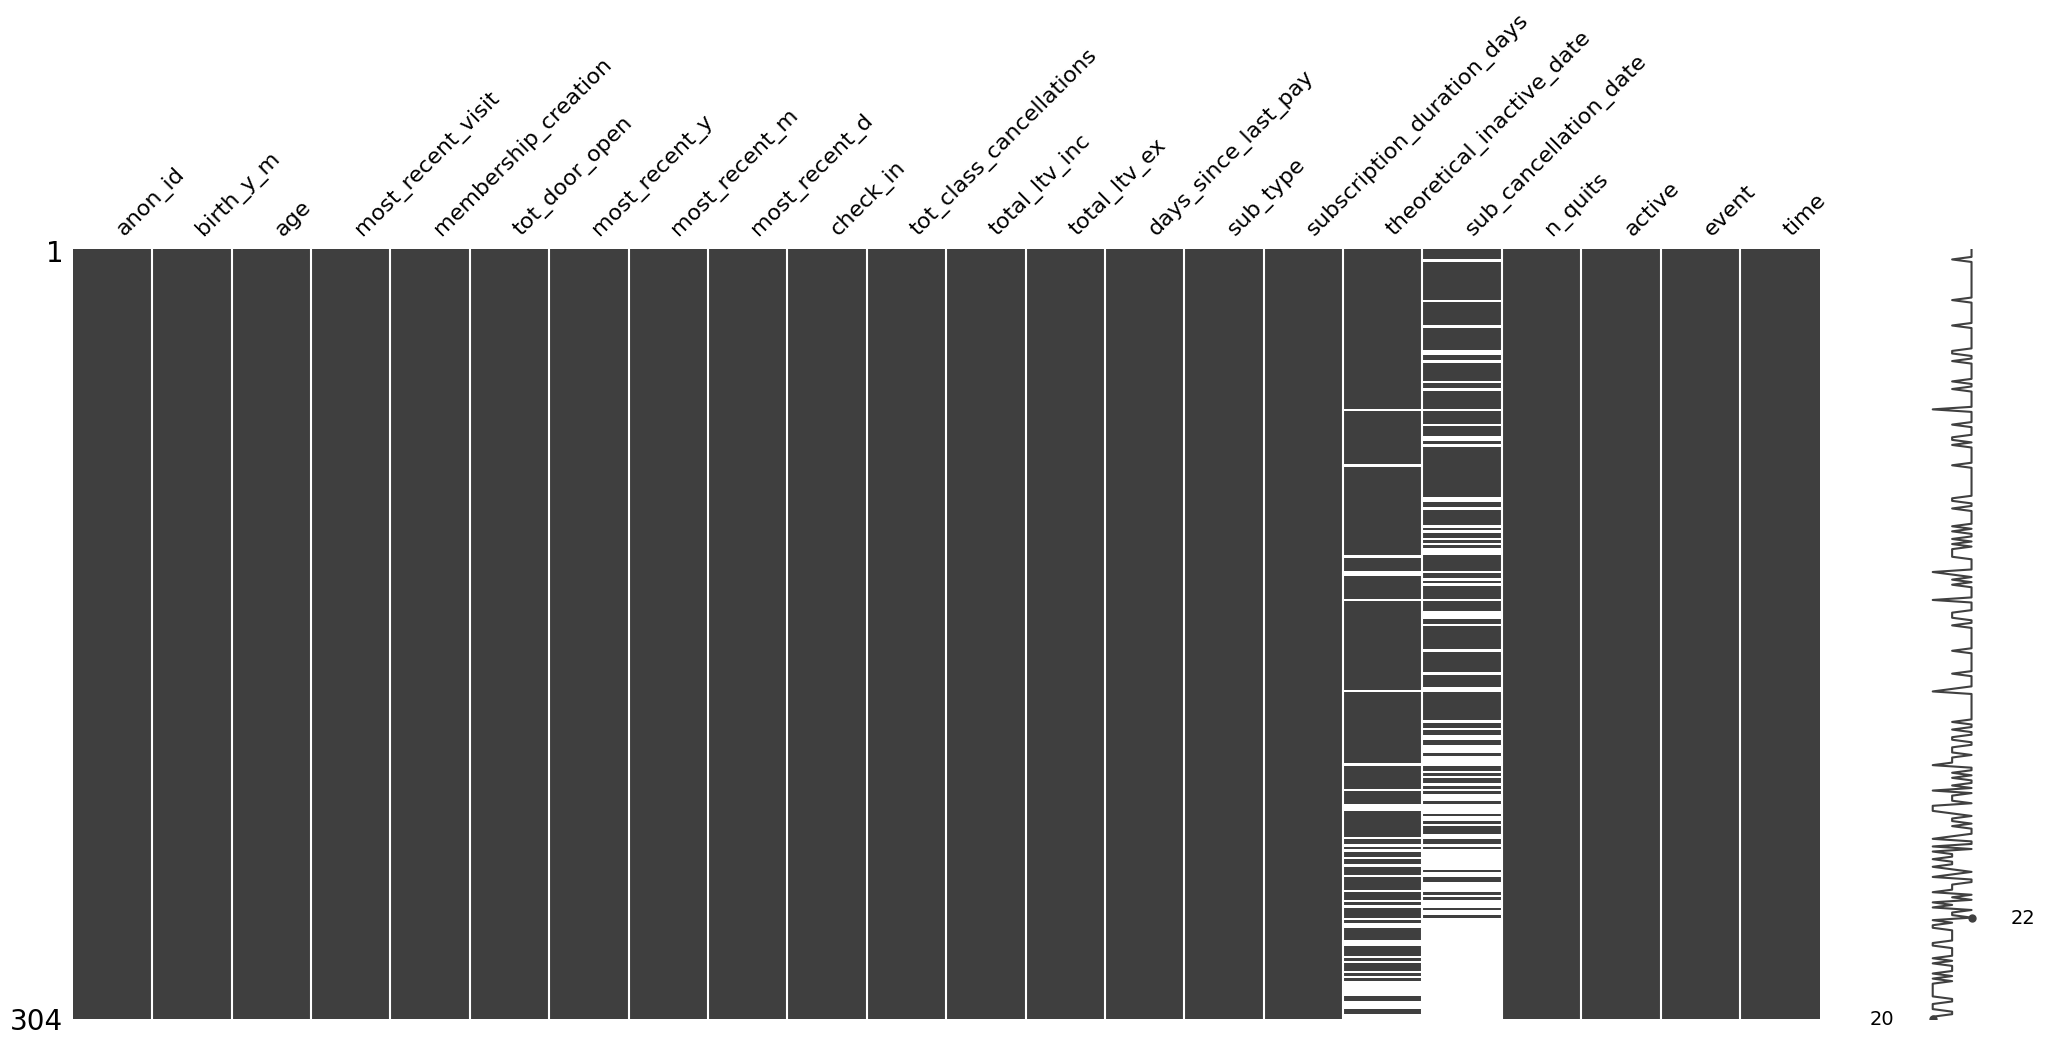

In [19]:
msno.matrix(df)
plt.show()

In [20]:
# Sub cancelation date SHOULD be a bunch of nans.
# But double checking wether any active members have a cancelation date
print("Active members with cancellation date:")
print(df[(df['active'] == 'yes') & (df['sub_cancellation_date'].notna())].shape[0])
#Or any inactive members DONT have a cancelation date
print("\nInactive members without cancellation date:")
print(df[(df['active'] == 'no') & (df['sub_cancellation_date'].isna())].shape[0])

Active members with cancellation date:
0

Inactive members without cancellation date:
0


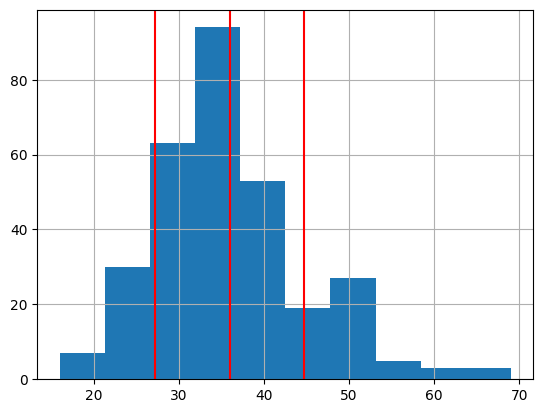

Mean age: 35.95 Std age: 8.74


In [21]:
def hist_w_std(dataframe,colname, meanstd=False):
    #Makes a histogram with mean and std vertical lines for fast scanning
    #can return actual mean and std if needed
    dataframe[colname].hist()
    plt.axvline(dataframe[colname].mean(), c="r")
    plt.axvline(dataframe[colname].mean()-dataframe[colname].std(), c="r")
    plt.axvline(dataframe[colname].mean()+dataframe[colname].std(), c="r")
    plt.show()
    if meanstd:
        return dataframe[colname].mean(),dataframe[colname].std()
agemean, agestd= hist_w_std(df, "age",meanstd=True)
print("Mean age:",np.round(agemean,2), "Std age:", np.round(agestd,2))

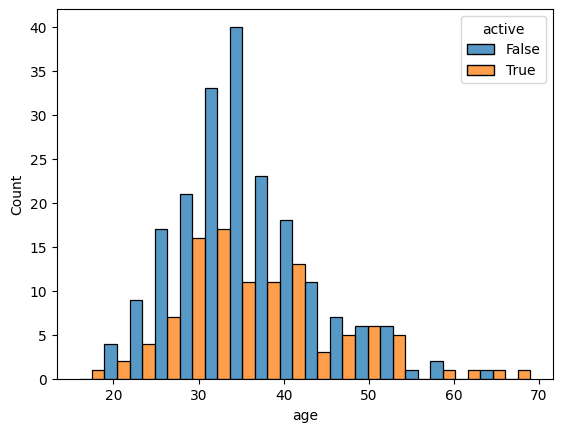

In [22]:
#Good thing i made a function for histograms only to realize i need seaborns flexibility for the first one
sns.histplot(data=df, x="age",hue="active", multiple="dodge")
plt.show()

The age numbers are confirmed to be in line with owners knowledge of a typical member.

In [23]:
df["sub_type"].value_counts()

sub_type
crossfit_12_mån_autogiro_fullt_medlemskap            94
crossfit_6_mån_autogiro_fullt_medlemskap             87
crossfit_12_mån_autogiro_student_fullt_medlemskap    24
klippkort_-_entré                                    24
intro_brons_autogiro                                 16
crossfit_6_mån_autogiro_student_fullt_medlemskap     11
crossfit_12_mån_autogiro_open_gym                    11
veckokort_2                                          10
1_månads_fullt_medlemskap                             7
skåpshyra_12_mån_autogiro                             6
teens_autogiro                                        5
crossfit_12_mån_autogiro_student_open_gym             4
fbb_ag_6mån                                           2
crossfit_6_mån_autogiro_open_gym                      2
hyrox_ag_12mån                                        1
Name: count, dtype: int64

Most customers have (had) a yearly lock in time then followed by monthly direct debit   
Closely followed by 6 month lock in with the same debit  
Dont like the many small type memberships. Domain knowledge says its old types of subscriptions mostly.    
Will colapse them into "other"

In [24]:

rare_threshold = 9 #setting this by eyeballing output above

value_counts = df['sub_type'].value_counts()  #storing valuecounts for comparing
rare_subs = value_counts[value_counts < rare_threshold].index

df['sub_type'] = df['sub_type'].apply(
    # if value counts is less than threshold rename into "other"
    # else keep the old category name
    lambda x: 'other' if x in rare_subs else x
)
df['sub_type'].value_counts()

sub_type
crossfit_12_mån_autogiro_fullt_medlemskap            94
crossfit_6_mån_autogiro_fullt_medlemskap             87
other                                                27
klippkort_-_entré                                    24
crossfit_12_mån_autogiro_student_fullt_medlemskap    24
intro_brons_autogiro                                 16
crossfit_12_mån_autogiro_open_gym                    11
crossfit_6_mån_autogiro_student_fullt_medlemskap     11
veckokort_2                                          10
Name: count, dtype: int64

Much better

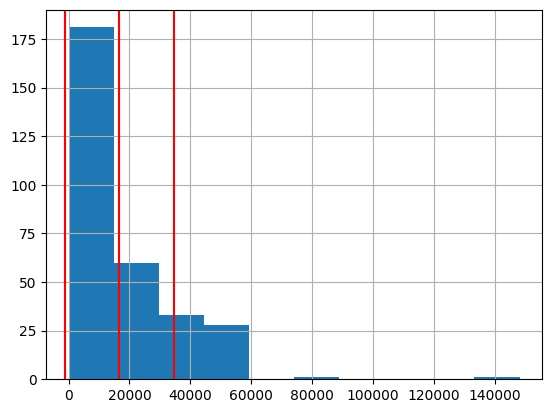

count       304.000000
mean      16753.457564
std       18018.531879
min          41.000000
25%        3365.250000
50%       10756.000000
75%       23153.750000
max      148218.000000
Name: total_ltv_inc, dtype: float64


In [25]:
hist_w_std(df,"total_ltv_inc")

print(df["total_ltv_inc"].describe())

Very right skewed tail. Not surprising, given that some members have records since the start of this dataset.  
And even further back (domain knowledge)  
Outliers, even the extreme one is a real member so I will keep it.

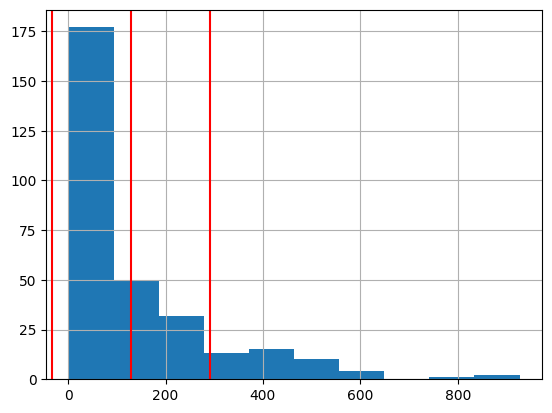

In [26]:
hist_w_std(df, "check_in")

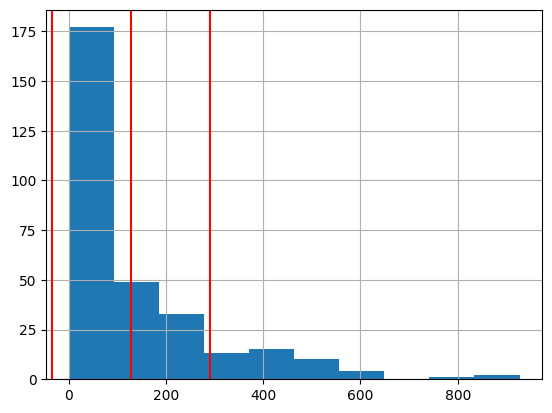

In [27]:

hist_w_std(df, "tot_door_open")


Door open and check in are suspiciously similar...

In [28]:
df[['tot_door_open', 'check_in']].corr()

,tot_door_open,check_in
tot_door_open,1.000000,0.999859
check_in,0.999859,1.000000


I thought door open and check_in were different based on original source and poking at raw csvs. Turns out i was wrong!

In [29]:
#dropping redundat col
df=df.drop(columns='tot_door_open')

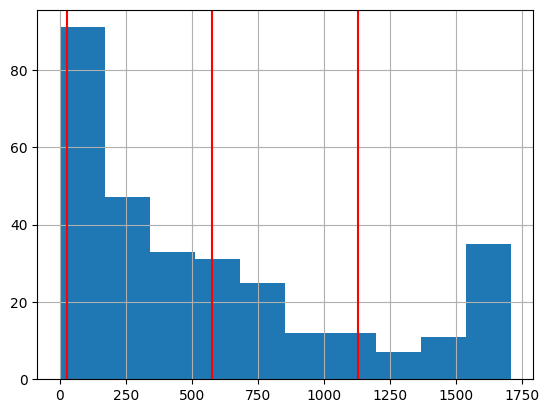

In [30]:
hist_w_std(df,"subscription_duration_days")

Long tails in general since some members are "lifers"

Chi-square test p-value: 0.5752917464584288


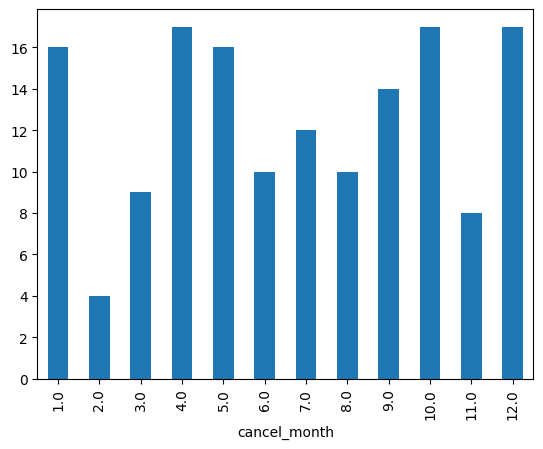

In [31]:
#Checking for any obvious monthly patterns.

# getting cancellation month
df['cancel_month'] = pd.to_datetime(df['sub_cancellation_date']).dt.month

# Plot cancellations by calendar month
df[df['event'] == True]['cancel_month'].value_counts().sort_index().plot(kind='bar')

#Had some LLM help to sort this code. But suggested chi2 myself since it should be multiple categorical comparisons
# Test if distribution differs from uniform
observed = df[df['event'] == True]['cancel_month'].value_counts().sort_index()
chi2, p = chi2_contingency([observed, [observed.mean()]*12])[:2]
print(f"Chi-square test p-value: {p}")

In [32]:
df['last_visit_month'] = pd.to_datetime(df['most_recent_visit']).dt.month

# Check distribution across active/churned
df.groupby('event')['last_visit_month'].value_counts().unstack(fill_value=0)

# Chi-square test
contingency = pd.crosstab(df['event'], df['last_visit_month']) #comparing members visit patterns by sorting them into active or not
chi2, p = chi2_contingency(contingency)[:2]
print(f"p-value: {p}")

p-value: 1.269574794772804e-22


Seems like theres a difference in distribution of last visit between active and canceled members!

In [33]:
#second guessing myself
contingency

last_visit_month,1,2,3,4,5,6,7,8,9,10,11,12
event,,,,,,,,,,,,
False,15,78,1,0,1,0,0,0,0,1,3,6
True,21,28,16,14,14,17,11,12,19,15,10,22


Tried extracting last visit month in order to try and capture some seasonality,  
But this table shows the obvious. Members who are not canceled will by definition have their latest visit in jan or feb.  
Duh!

In [34]:
#dropping experimental columns
df=df.drop(columns=["last_visit_month","cancel_month"])

# Feature engineering

In [35]:

df['days_since_last_visit'] = np.where(
    df['event'],
    # Churned: days between last visit and cancellation
    (df['sub_cancellation_date'] - df['most_recent_visit']).dt.days,
    # Active: days between last visit and reference date
    (REFERENCE_DATE - df['most_recent_visit']).dt.days
) 
# This code i needed claude for but the idea was all mine. 
# We need the days between the last visit and cancelation. 
# Otherwise old churned members might get extremely high numbers.

## Normalizing features by days rather than aggregated sum
Needed for survival analysis. Otherwise high aggregated values will leak y information.  
Expecting to use these for modelling  

In [36]:
#Doing frequency by month for interpretability. 
df["class_cancel_mnth"]=(df["tot_class_cancellations"]/df["time"]) * 30
df["payment_mnth"]=(df["total_ltv_inc"]/df["time"]) * 30
df["check_in_mnth"]=(df["check_in"]/df["time"])* 30

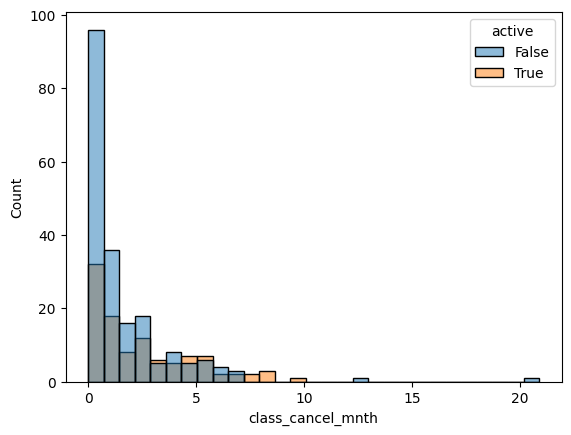

In [37]:
sns.histplot(data=df, x="class_cancel_mnth", hue="active")
plt.show()

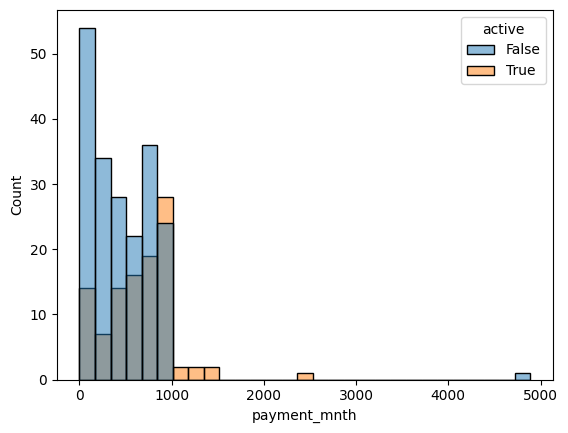

In [38]:
sns.histplot(data=df, x="payment_mnth", hue="active")
plt.show()

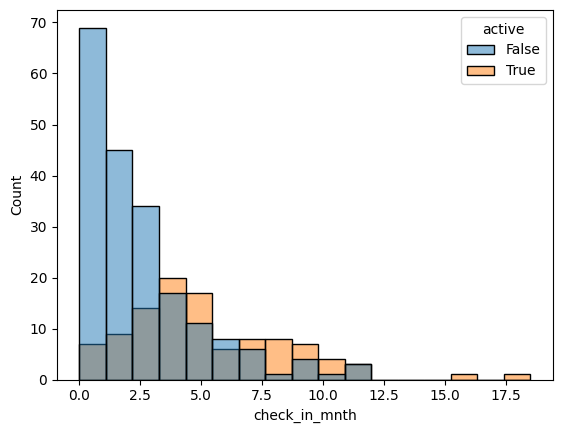

In [39]:
sns.histplot(data=df, x="check_in_mnth", hue="active")
plt.show()

In [40]:
(df['time'] == 0).sum()

np.int64(0)

In [41]:
df["time"].describe()

count          304.0
mean     1526.029605
std      2530.438682
min             22.0
25%           331.75
50%            739.0
75%           1697.5
max          13193.0
Name: time, dtype: Float64

That max number is impossible! ~30 years

In [42]:
# Seems like theres some placeholder values
print(f"Members with impossible creation dates 1990-01-01: {(df['membership_creation'] == '1990-01-01').sum()}")

# Dropping
df = df[df['membership_creation'] != '1990-01-01']


Members with impossible creation dates 1990-01-01: 13


In [43]:
df['time'].max(), df['time'].max()/365


(np.int64(3664), np.float64(10.038356164383561))

This is still kinda weird since the system was set up ~2021.  
But the gym was established 2012 might be customer migration funkiness.  
Hope to find the vast majority membership creations to be 2021

In [44]:
# Counting how many creations are made each year
df.groupby(df['membership_creation'].dt.year)['anon_id'].count()

membership_creation
2013     1
2016    17
2017    15
2018    17
2019    13
2020    24
2021    58
2022    35
2023    29
2024    39
2025    39
2026     4
Name: anon_id, dtype: int64

In [45]:
df[df['membership_creation'] == df['membership_creation'].min()]

,anon_id,birth_y_m,age,most_recent_visit,membership_creation,most_recent_y,most_recent_m,most_recent_d,check_in,tot_class_cancellations,total_ltv_inc,total_ltv_ex,days_since_last_pay,sub_type,subscription_duration_days,theoretical_inactive_date,sub_cancellation_date,n_quits,active,event,time,days_since_last_visit,class_cancel_mnth,payment_mnth,check_in_mnth
13,e0d7998e-28ac-4b53-8075-0cd4f1e4c313,1994-11-01,32,2021-09-02 15:15:00,2013-10-28,2021,9,2,19,0,2916.0,2750.93,1627,crossfit_12_mån_autogiro_fullt_medlemskap,92,2021-09-26,2021-08-26,2,False,True,2890,-8.0,0.0,30.269896,0.197232


So much for hope.  
Its a bad idea to drop everything before 2021 but that 2013 outlier will create issues.  
The numbers are weird too. 92 subscription days for a yearly membership, 0.2 check ins per month  


In [46]:
# Dropping everything before 2016
df = df[df['membership_creation'].dt.year >= 2016]

In [47]:
df[df['time'] == df['time'].max()]

,anon_id,birth_y_m,age,most_recent_visit,membership_creation,most_recent_y,most_recent_m,most_recent_d,check_in,tot_class_cancellations,total_ltv_inc,total_ltv_ex,days_since_last_pay,sub_type,subscription_duration_days,theoretical_inactive_date,sub_cancellation_date,n_quits,active,event,time,days_since_last_visit,class_cancel_mnth,payment_mnth,check_in_mnth
14,953f1e79-b079-4188-acb3-113bc8ab4e01,1986-01-01,40,2026-02-09 18:06:00,2016-02-03,2026,2,9,278,138,45806.0,43213.05,44,crossfit_12_mån_autogiro_student_fullt_medlemskap,1675,2026-01-28,2020-05-13,1,True,False,3664,4.0,1.129913,375.049127,2.276201


This one looks much more reasonable.

In [48]:
df["time"].describe()

count          290.0
mean     1022.603448
std       930.624472
min             22.0
25%           312.25
50%            689.0
75%           1547.5
max           3664.0
Name: time, dtype: Float64

This looks much more reasonable

In [49]:
df.shape

(290, 25)

## KM Curve

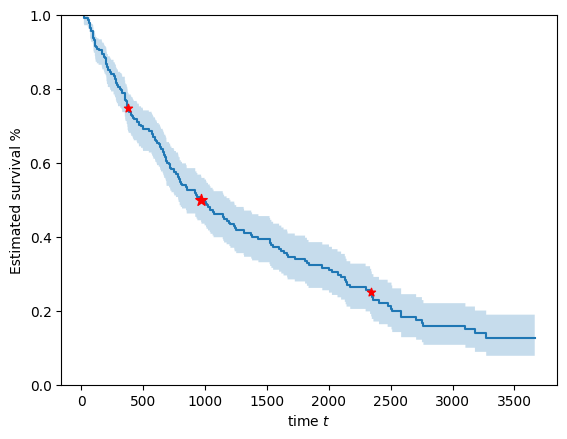

In [50]:
#Arguments are largely based on sksurv docs samples and im not 100% what everything does
# Create sksurv fitted arr
y = Surv.from_arrays(event=df['event'], time=df['time'])

#                                                      event,       time exit   left censored data arguments             
time, survival_prob, conf_int = kaplan_meier_estimator(y['event'], y['time'], time_enter=None, time_min=None,  
                                                       reverse=False, conf_level=0.95, conf_type="log-log")
#                                                   Above my paygrade  uncertainity band    how CI is calculated (above paygrade)


#Finding percentiles for business metrics
first_perc_idx = np.where(survival_prob <= 0.75)[0][0]
first_perc_time = time[first_perc_idx]
median_idx = np.where(survival_prob <= 0.5)[0][0]
median_time = time[median_idx]
thrid_perc_idx = np.where(survival_prob <= 0.25)[0][0]
third_perc_time = time[thrid_perc_idx]



#literal copy of sksurv docs + percentile dots
plt.step(time, survival_prob, where="post")
plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")


# Adding some dots for percentiles
plt.scatter(first_perc_time, 0.75, c="r", marker="*",zorder=5)
plt.scatter(median_time, 0.5, c="r",marker="*", s=75, zorder=5)
plt.scatter(third_perc_time, 0.25, c="r",marker="*",zorder=5)

plt.ylim(0, 1)



plt.ylabel(r"Estimated survival %")
plt.xlabel("time $t$")
plt.show()


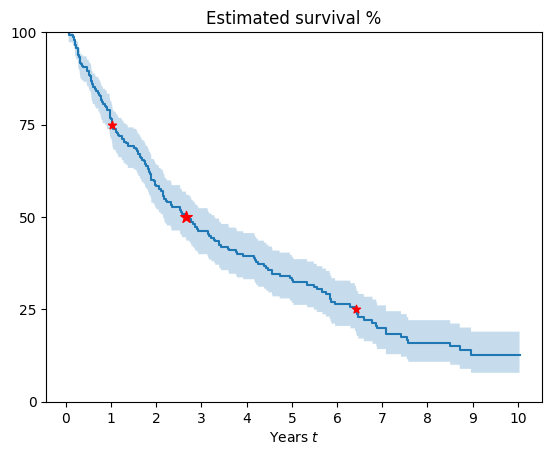

In [51]:
#Arguments are largely based on sksurv docs samples and im not 100% what everything does
# Create sksurv fitted arr
y = Surv.from_arrays(event=df['event'], time=df['time'])

#                                                      event,       time exit   left censored data arguments             
time, survival_prob, conf_int = kaplan_meier_estimator(y['event'], y['time'], time_enter=None, time_min=None,  
                                                       reverse=False, conf_level=0.95, conf_type="log-log")
#                                                   Above my paygrade  uncertainity band    how CI is calculated (above paygrade)


#Finding percentiles for business metrics
first_perc_idx = np.where(survival_prob <= 0.75)[0][0]
first_perc_time = time[first_perc_idx]
median_idx = np.where(survival_prob <= 0.5)[0][0]
median_time = time[median_idx]
thrid_perc_idx = np.where(survival_prob <= 0.25)[0][0]
third_perc_time = time[thrid_perc_idx]



#literal copy of sksurv docs + percentile dots
plt.step(time, survival_prob, where="post")
plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")


# Adding some dots for percentiles
plt.scatter(first_perc_time, 0.75, c="r", marker="*",zorder=5)
plt.scatter(median_time, 0.5, c="r",marker="*", s=75, zorder=5)
plt.scatter(third_perc_time, 0.25, c="r",marker="*",zorder=5)

plt.ylim(0, 1)
plt.xticks(np.arange(0, np.max(time), step=365), labels=np.arange(0, np.max(time)//365 + 1).astype(int))
plt.yticks(np.arange(0, 1.1, 0.25), labels=[0, 25, 50, 75, 100])


plt.title(r"Estimated survival %")
plt.xlabel("Years $t$")
plt.show()




In [52]:
#bussiness metrics! Numbers assumes montly 12 month subscription price. 
# Would be slightly higher if members did 6 month and obviously lower for current members locked in at lower prices.
print(f"First percentile survival time: {first_perc_time} days, first percentile subscription ltv: {int((first_perc_time/365)*964*12)}kr")
print(f"Median survival time: {median_time} days, median subscription ltv: {int((median_time/365)*964*12)}kr")
print(f"Third percentile survival time: {third_perc_time} days, third percentile subscription ltv: {int((third_perc_time/365)*964*12)}kr")

First percentile survival time: 376.0 days, first percentile subscription ltv: 11916kr
Median survival time: 972.0 days, median subscription ltv: 30805kr
Third percentile survival time: 2343.0 days, third percentile subscription ltv: 74257kr


Here we can clearly see the "lifer" members.  
Added percentile markers and estimated expected value at these points.  
This kind of flat line should break cox assumptions?

# Train test split and imputation

In [53]:
features = ['age', 'payment_mnth', "check_in_mnth",'class_cancel_mnth',
            'sub_type','n_quits']


print("Selected features included:", features)

Selected features included: ['age', 'payment_mnth', 'check_in_mnth', 'class_cancel_mnth', 'sub_type', 'n_quits']


In [54]:
#splitting 80/20 CV will have to cover for small dataset
df_train, df_test = train_test_split(df, train_size=0.8, test_size=0.2, random_state=RANDOM_STATE)

#making separate dfs for exploring and modelling
anon=["anon_id"]
target_cols=["event", "time"]
df_train_xy=df_train[anon+features+target_cols].copy()
df_test_xy=df_test[anon+features+target_cols].copy()

# modelling dfs
train_data_x = df_train[features].copy()
train_data_y = df_train[target_cols].copy()

test_data_x = df_test[features].copy()
test_data_y = df_test[target_cols].copy()


In [55]:
#NOTE keeping this for legacy and documentation
# Prior to the colapsing of categories test randomly got a sub type category that wasnt in train.
# Imputed the most common from train in order to avoid data leakage to model (even if data has leaked to my brain!)

# # Get all unique categories from train
# train_cats = train_data_x['sub_type'].astype("category").cat.categories

# # Force test to use same categories (unseen ones become NaN, then fill with mode)
# test_data_x['sub_type'] = test_data_x['sub_type'].astype("category").cat.set_categories(train_cats)

# # Fill any NaNs with the most common category from train
# mode_sub = train_data_x['sub_type'].mode()[0]
# test_data_x['sub_type'] = test_data_x['sub_type'].fillna(mode_sub)

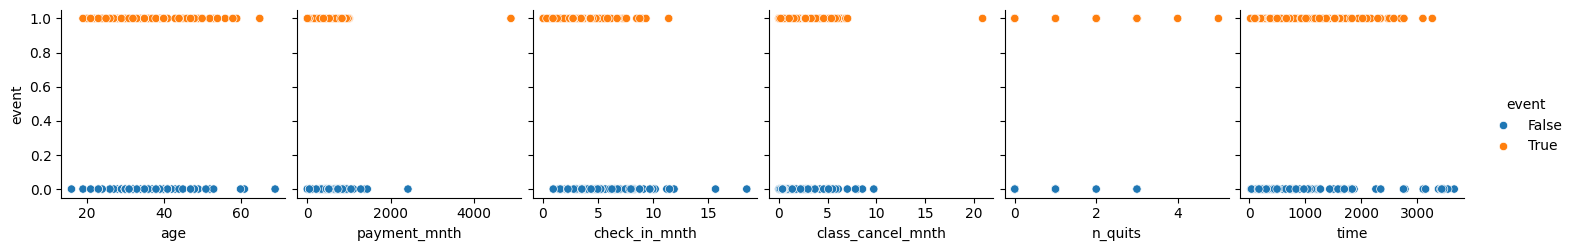

In [56]:
sns.pairplot(data=df_train[features+target_cols], y_vars="event", hue="event")
plt.show()

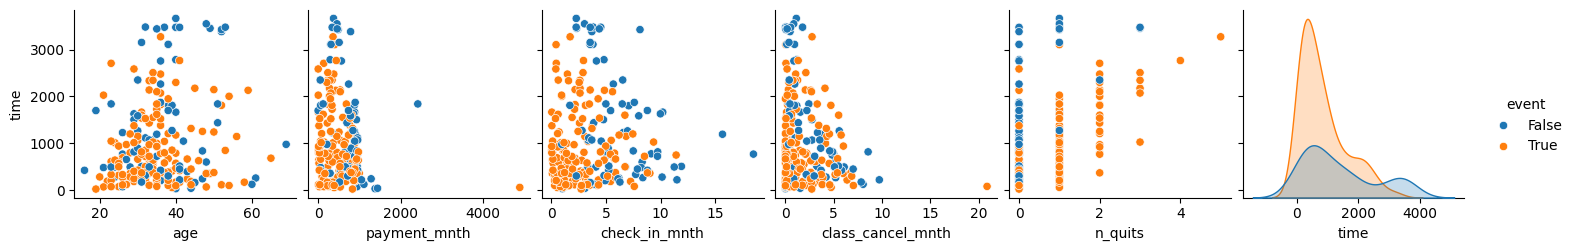

In [57]:
sns.pairplot(data=df_train[features+target_cols], y_vars="time", hue="event")
plt.show()

No super clean separations. This is some real messy real data. I'll be happy if model hits 0.6 C-index

### Double checking missing values

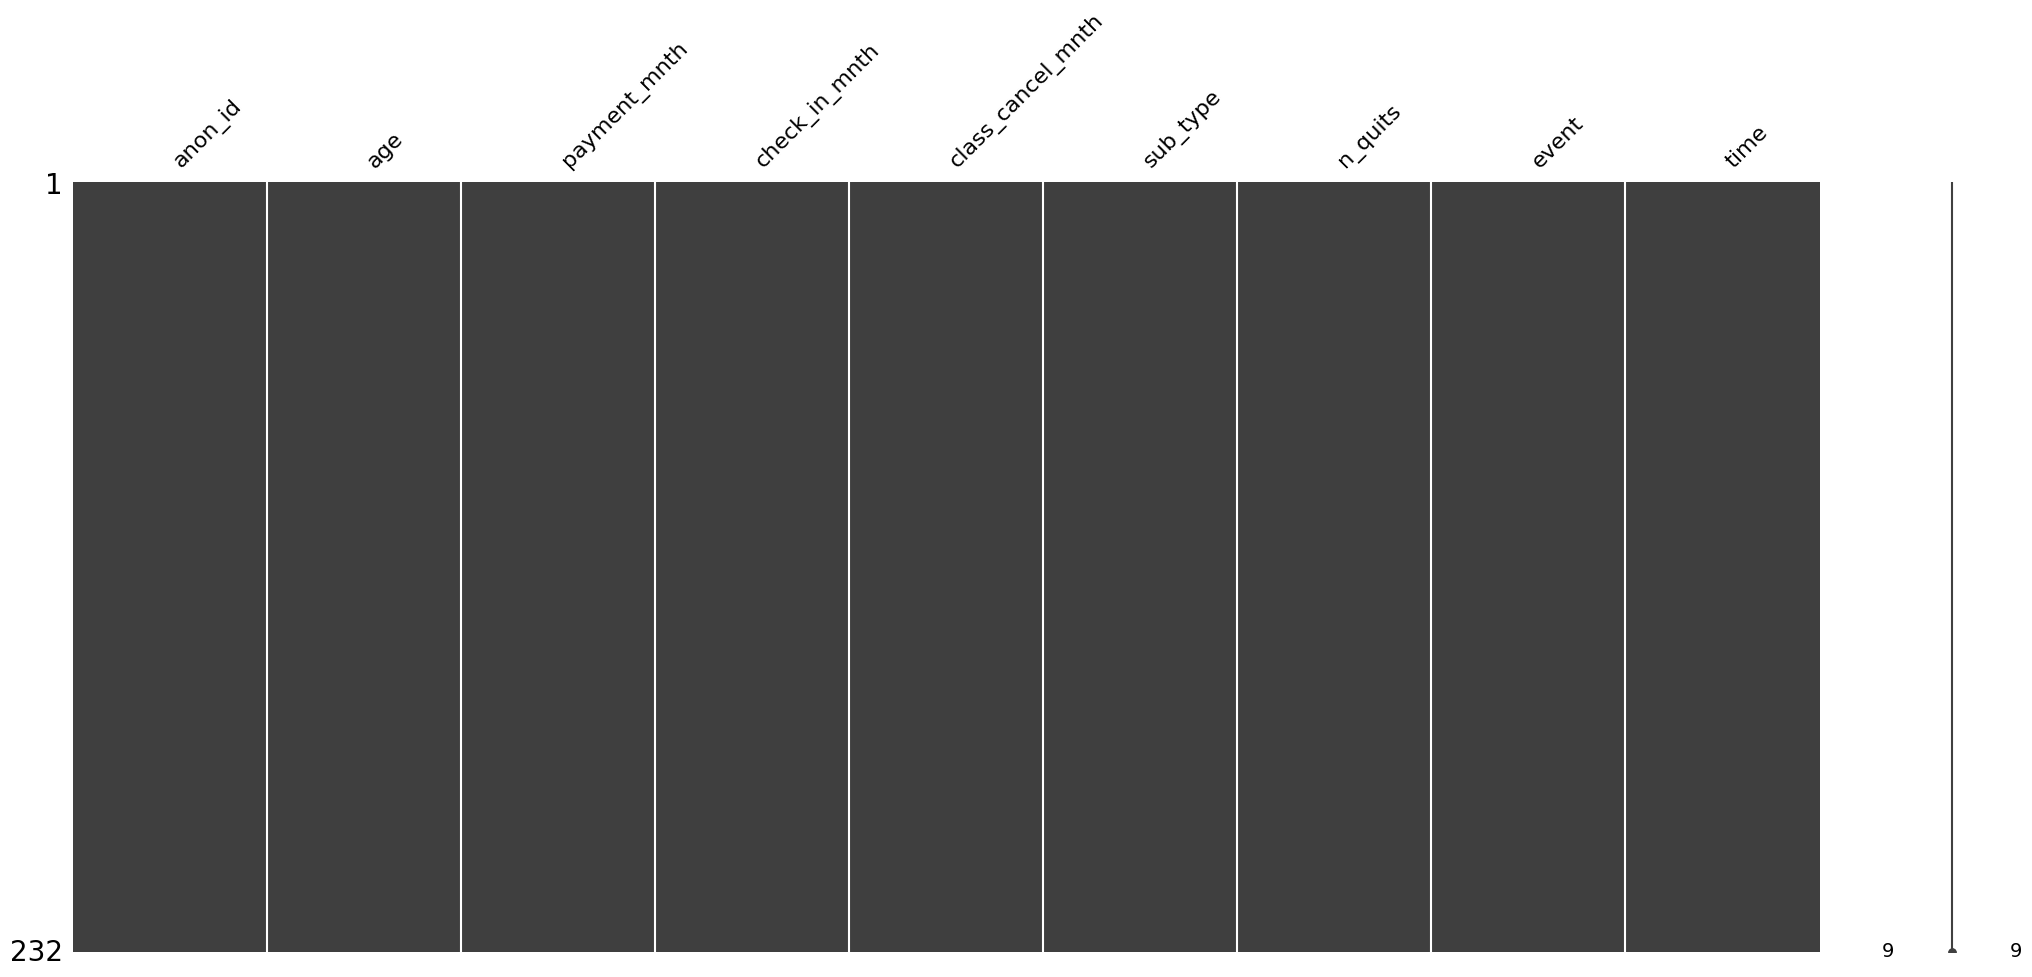

In [58]:
msno.matrix(df_train_xy) #days since last visit ect
plt.show()

In [59]:
df_train_xy.isna().sum(), df_test_xy.isna().sum()

(anon_id              0
 age                  0
 payment_mnth         0
 check_in_mnth        0
 class_cancel_mnth    0
 sub_type             0
 n_quits              0
 event                0
 time                 0
 dtype: int64,
 anon_id              0
 age                  0
 payment_mnth         0
 check_in_mnth        0
 class_cancel_mnth    0
 sub_type             0
 n_quits              0
 event                0
 time                 0
 dtype: int64)

Nans seem fine right now

## Correlation matrix

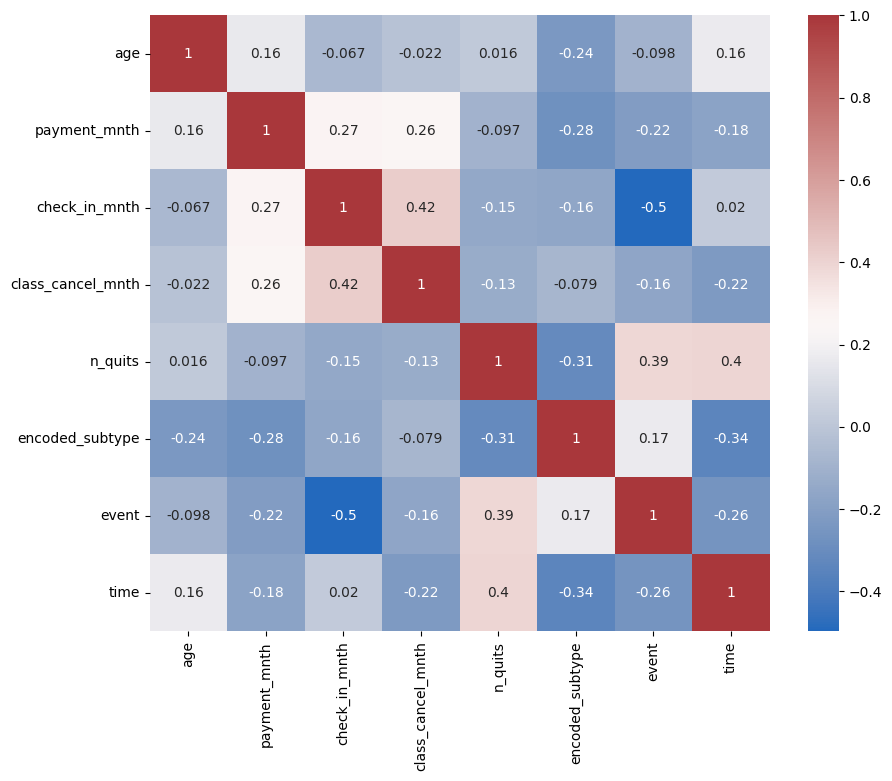

In [60]:

encoded_subtype = LabelEncoder().fit_transform(df_train['sub_type']) #making dummyencoding for CM in order to make things more readable
temp_train_df_corrcheck=df_train_xy.copy()
temp_train_df_corrcheck["encoded_subtype"]=encoded_subtype
temp_train_df_corrcheck=temp_train_df_corrcheck.drop(columns=["anon_id", "sub_type"])

temp_train_df_corrcheck=temp_train_df_corrcheck[['age', 'payment_mnth', 'check_in_mnth', 'class_cancel_mnth',  
                                                'n_quits','encoded_subtype','event', 'time']] #reordering for readability


fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(temp_train_df_corrcheck.corr(), annot=True, fmt=".2g", ax=ax, cmap="vlag") #I love Seaborn
plt.show()


No obvious high colinearity between feature |<0.5|.    
All features have ~|15-30%| colinearity with time.  
And apart from age-event we see similar colinearity between features and event ~|15-45%|

In [ ]:
## NOTE REMOVED SINCE DAYS_SINCE_LAST_VISIT WAS CORRUPTED SEE REPORT FOR MORE INFO. Keeping for documentation

# #train impute
# member_tenure_threshold=30 
# train_days_since_last_visit_median=train_data_x["days_since_last_visit"].median() #storing for test impute

# train_data_x["days_since_last_visit"]=np.where((train_data_x["days_since_last_visit"].isna())& # if double bool
#                                                (train_data_x["tenure"]<member_tenure_threshold), 
#                                                0, #then assume the member is new and havent had time to open the door and impute 0
#                                                np.where(train_data_x["days_since_last_visit"].isna(), # else by nesting where clause
#                                                         train_days_since_last_visit_median,
#                                                         train_data_x['days_since_last_visit']
#                                                         )
#                                                )


# test_data_x["days_since_last_visit"]=np.where((test_data_x["days_since_last_visit"].isna())& # if double bool
#                                                (test_data_x["tenure"]<member_tenure_threshold), 
#                                                0, #then assume the member is new and havent had time to open the door and impute 0
#                                                np.where(test_data_x["days_since_last_visit"].isna(), # else by nesting where clause
#                                                         train_days_since_last_visit_median,
#                                                         test_data_x['days_since_last_visit']
#                                                         )
#                                                )


In [ ]:
# I guess standardscaler but coulndt find anything conclusive
# https://www.nature.com/articles/s42256-024-00932-5
# Minmax would handle the tailed dists and the few outliers better
# But standard is easier to understand and keeps a more even spread of values
# And cox is linear, generally standardscale for linear afaik


#SHAMELESSLY STOLEN FROM LAB 2
num_cols = train_data_x.select_dtypes(include=["int64", "float64"]).columns #numerical columns

scaler=StandardScaler()

scaled_train_data_x = train_data_x.copy()
scaled_test_data_x = test_data_x.copy()

# Scaling numerical columns
scaled_train_data_x[num_cols]=scaler.fit_transform(train_data_x[num_cols])
scaled_test_data_x[num_cols]=scaler.transform(test_data_x[num_cols])

# Converting subscription type via OHE. More columns, harder to read but better information capture than dummy encoding
scaled_train_data_x['sub_type'] = train_data_x['sub_type'].astype('category')
scaled_test_data_x['sub_type'] = test_data_x['sub_type'].astype('category')

membership_encoder=OneHotEncoder() 
#sksurvs OHE should be named OneHotSurvEncoder or something as it shares method name with sklearns but functions differently

#Sksurv OneHotEncoder handles the whole DataFrame (scaled numerics + categorical)! Its almost cheating
X_train_sc_e = membership_encoder.fit_transform(scaled_train_data_x[features])
X_test_sc_e = membership_encoder.transform(scaled_test_data_x[features])


# Getting a sense of how models work and perform on training data
These should more be considered as eda. Full CV and test evaluation below.

### Cox

In [ ]:
# Convert targets to surv arrays
y_train = Surv.from_arrays(
    event=train_data_y['event'].values, 
    time=train_data_y['time'].values
)
y_test = Surv.from_arrays(
    event=test_data_y['event'].values, 
    time=test_data_y['time'].values
)
# Fit Cox PH
cox_estimator = CoxPHSurvivalAnalysis()
cox_estimator.fit(X_train_sc_e, y_train)

train_risk_multi = cox_estimator.predict(X_train_sc_e)

c_train_multi = concordance_index_censored(y_train['event'], y_train['time'], train_risk_multi)[0] 
#[0] for c index only. Because the method returns a bunch of stuff that is above my paygrade until i read the mlsurv book

print(f"All features Cox C-index: {c_train_multi:.3f}")

All features Cox C-index: 0.769


This is surprisingly good! Given KM curve, imputations, data quality issues and small dataset.


Testing cox on one feature at a time

In [ ]:
# comparison table
comparison = []

# Univariate results
for col in X_train_sc_e.columns:
    X_train_single = X_train_sc_e[[col]] 
    single_cox = CoxPHSurvivalAnalysis().fit(X_train_single, y_train) #hey I can do this in one line!

    risk_scores_train = single_cox.predict(X_train_single)
    c_single_train = concordance_index_censored(
        y_train['event'], 
        y_train['time'], 
        risk_scores_train
    )[0]

    comparison.append({
        'feature': f"{col}",
        'univariate_coef': single_cox.coef_[0],
        'univariate_cindex_train': c_single_train,
    })

comparison_df = pd.DataFrame(comparison)
comparison_df.sort_values(by="univariate_cindex_train", ascending=False).round(3)

,feature,univariate_coef,univariate_cindex_train
2,check_in_mnth,-0.579,0.626
8,sub_type=intro_brons_autogiro,3.832,0.572
0,age,-0.234,0.559
12,n_quits,-0.051,0.552
9,sub_type=klippkort_-_entré,1.017,0.535
11,sub_type=veckokort_2,0.987,0.517
6,sub_type=crossfit_6_mån_autogiro_fullt_medlemskap,0.233,0.516
10,sub_type=other,-0.133,0.512
5,sub_type=crossfit_12_mån_autogiro_student_full...,-0.057,0.510
4,sub_type=crossfit_12_mån_autogiro_open_gym,-0.654,0.510


Any feature alone is barely better than chance apart from check ins and intro brons.  
Age and n_quits gets honorable mentions but..not really

### L1 Coefficents

In [ ]:
# NOTE:
# Claude provided code as sksurv L1 seems to do some form of gridsearch across l1 alpha values since I got 13,100 shape and didnt know what it meant
# In a nutshell CoxnetSurvivalAnalysis sort of works as elasticnet linear regression from sklearn
# But I still dont understand what happens under the hood other than "features surviving often are most likely important"

l1_estimator = CoxnetSurvivalAnalysis(l1_ratio=1.0, #Pure L1 for feature importance
                                      alpha_min_ratio=0.01, #lowest alpha value
                                      n_alphas=100) #how many different alpha values tested
l1_estimator.fit(X_train_sc_e, y_train)

#grabbing "surviving" features
nonzero_features = (l1_estimator.coef_ != 0).sum(axis=1)


print("The more times a feature survived l1 the more important it is (according to model)") 
for feature, n_survs in zip(X_train_sc_e.columns,nonzero_features):
    print(feature, n_survs)

l1_preds=l1_estimator.predict(X_train_sc_e)
ci_l1 = concordance_index_censored(y_train['event'], y_train['time'], l1_preds)[0] 
ci_l1
print(f"L1 Cox C-index: {ci_l1:.3f}")

The more times a feature survived l1 the more important it is (according to model)
age 86
payment_mnth 73
check_in_mnth 99
class_cancel_mnth 79
sub_type=crossfit_12_mån_autogiro_open_gym 0
sub_type=crossfit_12_mån_autogiro_student_fullt_medlemskap 26
sub_type=crossfit_6_mån_autogiro_fullt_medlemskap 43
sub_type=crossfit_6_mån_autogiro_student_fullt_medlemskap 30
sub_type=intro_brons_autogiro 67
sub_type=klippkort_-_entré 52
sub_type=other 36
sub_type=veckokort_2 44
n_quits 71
L1 Cox C-index: 0.769


No real difference in C-index from vanilla cox.  
Not quite sure what to make of the feature importance numbers.

## Tree

In [ ]:
tree_restults=[]

# just a quick minituning
depths=[5,10,15]
min_samples_leaf=[6,10]

for d in depths:
    for s in min_samples_leaf:
        
        yew_tree=SurvivalTree(splitter='best', max_depth=d, min_samples_split=6, min_samples_leaf=s, 
                            min_weight_fraction_leaf=0.0, max_features=None, random_state=RANDOM_STATE, 
                            max_leaf_nodes=None, low_memory=False)
                            #this really feels like sklearn tree arguments atleast depth and split stuff

        yew_tree.fit(X_train_sc_e, y_train)

        train_risk_tree = yew_tree.predict(X_train_sc_e)
        test_risk_tree = yew_tree.predict(X_test_sc_e)

        c_train_tree = concordance_index_censored(y_train['event'], y_train['time'], train_risk_tree)[0]

        tree_restults.append({
            'tree hyperparams': (d,s),
            'cindex_train': c_train_tree
        })

tree_df=pd.DataFrame(tree_restults)
tree_df.round(4)


,tree hyperparams,cindex_train
0,"(5, 6)",0.8062
1,"(5, 10)",0.7982
2,"(10, 6)",0.8636
3,"(10, 10)",0.8164
4,"(15, 6)",0.8636
5,"(15, 10)",0.8164


Even a shallow tree outperforms cox ph. Not surprising.

## Forest

In [ ]:
forest_restults=[]
#quick minituning here as well to get a sense
estimators=[50,150,200]
depths=[5,10, None]

for e in estimators:
    for d in depths:
        #This is extremely similar to sklearn. Running the method here is easy.
        weirwood=RandomSurvivalForest(n_estimators=e, max_depth=d, min_samples_split=6, 
                                    min_samples_leaf=3, min_weight_fraction_leaf=0.0, max_features='sqrt', 
                                    max_leaf_nodes=None, bootstrap=True, oob_score=True, n_jobs=None, random_state=RANDOM_STATE, 
                                    verbose=0, warm_start=False, max_samples=None, low_memory=False)
        weirwood.fit(X_train_sc_e, y_train)

        train_risk_forest = weirwood.predict(X_train_sc_e)
        test_risk_forest = weirwood.predict(X_test_sc_e)

        c_train_forest = concordance_index_censored(y_train['event'], y_train['time'], train_risk_forest)[0]

        forest_restults.append({
            'forest hyperparams': (e,d),
            'cindex_train': c_train_forest,
            "oob_score": weirwood.oob_score_ #I love oob
        })

forest_df=pd.DataFrame(forest_restults)
forest_df.round(4)

,forest hyperparams,cindex_train,oob_score
0,"(50, 5)",0.8357,0.7572
1,"(50, 10)",0.8825,0.7798
2,"(50, None)",0.8835,0.7821
3,"(150, 5)",0.8486,0.7798
4,"(150, 10)",0.8829,0.7806
5,"(150, None)",0.8835,0.7809
6,"(200, 5)",0.8493,0.7810
7,"(200, 10)",0.8824,0.7830
8,"(200, None)",0.8839,0.7843


Bit high on the overfitting based on oob scoring. Ill include som conservative tree depths to gridsearch.

# Gridsearch!

Doing multiple GS rather than one giant block of code.
Easier to grab the best performance of each model for detailed comparisons later

In [ ]:
# Need custom scorer for sklearns gridsearch since it cant handle double ys
# Llm assited with solving the problem then i Ad hoc found documentation for GS scoring...on survival SVM page
# https://scikit-survival.readthedocs.io/en/stable/user_guide/survival-svm.html
def survival_scorer(estimator, X, y):
    predictions = estimator.predict(X)
    return concordance_index_censored(y['event'], y['time'], predictions)[0]



# Vanilla cox in next cell as it only needs a cv and no gs


# 2. Elasticnet Regularized Cox (CoxnetSurvivalAnalysis)
elasticnet_params = {
    'l1_ratio': [0.01,0.25, 0.5, 0.75, 1.0],  # Mix of L1/L2 just like sklearn
    'alpha_min_ratio': [0.001, 0.01, 0.1]
    # leaving n alphas at default, this gs is big enough as is
}
elasticnet_grid = GridSearchCV(CoxnetSurvivalAnalysis(fit_baseline_model=True, n_alphas=100), elasticnet_params, cv=5, scoring=survival_scorer)
#coxnet ~ elasticnet from sklearn


# Survival Tree
tree_params = {
    'max_depth': [3, 5, 10,20, None],
    'min_samples_split': [6, 10, 15, 20],
    'min_samples_leaf': [3, 5, 10, 15]
}
tree_grid = GridSearchCV(SurvivalTree(random_state=RANDOM_STATE), tree_params, cv=5, scoring=survival_scorer)

# Random Forest
forest_params = {
    'max_depth': [3, 5,10, None],
    'n_estimators': [50, 100,150, 200],  
    'min_samples_split': [6, 10,20],
    'min_samples_leaf': [3, 5,10],
    'max_features': ['sqrt', 5,7] #max features randomly selected each split floor(sqrt(len(columns)))=3
    # options include log2 but that floor rounds to 3 as well so i manually added 5 and 7. 
    # Doing len(columns) would remove one level of randomness and therefore decrease performance of the model
}

forest_grid = GridSearchCV(RandomSurvivalForest(random_state=RANDOM_STATE), forest_params, cv=5, scoring=survival_scorer)


In [ ]:
print("Starting GridSearch")
# Baseline Cox (no hyperparameters to tune)
cox = CoxPHSurvivalAnalysis()

#only crossval as there is no grid search to be done
cox_cv_scores = cross_val_score(
    cox, X_train_sc_e, y_train, 
    cv=5, 
    scoring=survival_scorer
)
#averaging cv scores for fair comparisson to the other models with proper gs
cox_cv_score=np.mean(cox_cv_scores)

#proper fitting train and test for full eval later
cox.fit(X_train_sc_e, y_train)
cox_train_preds=cox.predict(X_train_sc_e)
cox_test_preds=cox.predict(X_test_sc_e)


cox_train_cindex = concordance_index_censored(y_train['event'], y_train['time'], cox_train_preds)[0]
cox_test_cindex = concordance_index_censored(y_test['event'], y_test['time'], cox_test_preds)[0]
display(f"Train score: {np.round(cox_train_cindex,4)}, Test score {np.round(cox_test_cindex,4)}")

Starting GridSearch


'Train score: 0.7688, Test score 0.7235'

In [ ]:
#L1
elasticnet_grid.fit(X_train_sc_e, y_train)
best_elasticnet_score=elasticnet_grid.best_score_
best_elasticnet_model=elasticnet_grid.best_estimator_

train_best_elastic_preds=best_elasticnet_model.predict(X_train_sc_e)
test_best_elastic_preds=best_elasticnet_model.predict(X_test_sc_e)

elastic_train_cindex = concordance_index_censored(y_train['event'], y_train['time'], train_best_elastic_preds)[0]
elastic_test_cindex = concordance_index_censored(y_test['event'], y_test['time'], test_best_elastic_preds)[0]

display(f"Gs score:{np.round(best_elasticnet_score,4)} Train score:{np.round(elastic_train_cindex,4)} Test score:{np.round(elastic_test_cindex,4)}")
best_elasticnet_model

'Gs score:0.7486 Train score:0.7687 Test score:0.7244'

CoxnetSurvivalAnalysis(alpha_min_ratio=0.01, fit_baseline_model=True,
                       l1_ratio=1.0)

In [ ]:
tree_grid.fit(X_train_sc_e, y_train)
best_tree_score=tree_grid.best_score_
best_tree_model=tree_grid.best_estimator_

train_tree_preds=best_tree_model.predict(X_train_sc_e)
test_tree_preds=best_tree_model.predict(X_test_sc_e)

tree_train_cindex = concordance_index_censored(y_train['event'], y_train['time'], train_tree_preds)[0]
tree_test_cindex = concordance_index_censored(y_test['event'], y_test['time'], test_tree_preds)[0]

display(f"Gs score:{np.round(best_tree_score,4)} Train score:{np.round(tree_train_cindex,4)} Test score:{np.round(tree_test_cindex,4)}")
best_tree_model

'Gs score:0.7639 Train score:0.8401 Test score:0.7643'

SurvivalTree(max_depth=10, min_samples_split=20, random_state=42)

In [ ]:
forest_grid.fit(X_train_sc_e, y_train)
best_forest_score=forest_grid.best_score_
best_forest_model=forest_grid.best_estimator_

train_forestpreds=best_forest_model.predict(X_train_sc_e)
test_forestpreds=best_forest_model.predict(X_test_sc_e)

forest_train_cindex = concordance_index_censored(y_train['event'], y_train['time'], train_forestpreds)[0]
forest_test_cindex = concordance_index_censored(y_test['event'], y_test['time'], test_forestpreds)[0]

display(f"Gs score:{np.round(best_forest_score,4)} Train score:{np.round(forest_train_cindex,4)} Test score:{np.round(forest_test_cindex,4)}")
best_forest_model

'Gs score:0.7794 Train score:0.8735 Test score:0.7788'

RandomSurvivalForest(min_samples_split=10, n_estimators=150, random_state=42)

In [ ]:
# Ping when gs is done so I can read while waiting
import os
os.system("paplay /usr/share/sounds/freedesktop/stereo/complete.oga")  
print("GridSearch complete!")

GridSearch complete!


In [ ]:
#Storing all results in df
results = pd.DataFrame({
    'Model': ['Cox', 'Elasticnet Cox', 'Tree', 'Forest'],
    'CV Score': [cox_cv_score, best_elasticnet_score, best_tree_score, best_forest_score],
    "Train C-Index":[cox_train_cindex,elastic_train_cindex, tree_train_cindex,forest_train_cindex],
    'Test C-index': [cox_test_cindex, elastic_test_cindex, tree_test_cindex, forest_test_cindex],
    "CV-test Δ":[cox_cv_score-cox_test_cindex, elastic_train_cindex-elastic_test_cindex, 
                   best_tree_score-tree_test_cindex, best_forest_score-forest_test_cindex]
})

results.round(4)

,Model,CV Score,Train C-Index,Test C-index,CV-test Δ
0,Cox,0.7469,0.7688,0.7235,0.0234
1,Elasticnet Cox,0.7486,0.7687,0.7244,0.0444
2,Tree,0.7639,0.8401,0.7643,-0.0004
3,Forest,0.7794,0.8735,0.7788,0.0006


In [ ]:
def highlight_max(s, props=""):
    if s.dtype == object:  # skip string columns
        return [""] * len(s)
    return np.where(s == np.nanmax(s.values), props, "")


def highlight_min(s, props=""):
    if s.dtype == object:  # skip string columns
        return [""] * len(s)
    return np.where(s == np.min(s.values), props, "")

absres=["CV Score","Train C-Index",	"Test C-index"]
delta=["CV-test Δ"]


(results.style.format(precision=4, thousands=".", decimal=",").format_index(
    str.upper, axis=1)
    #.background_gradient(axis=None)
.apply(highlight_max, props="color:white;background-color:darkblue", axis=0, subset=absres)
#.apply(highlight_min, props="color:white;background-color:darkred", axis=0, subset=delta)
.hide(axis="index"))

MODEL,CV SCORE,TRAIN C-INDEX,TEST C-INDEX,CV-TEST Δ
Cox,"0,7469","0,7688","0,7235","0,0234"
Elasticnet Cox,"0,7486","0,7687","0,7244","0,0444"
Tree,"0,7639","0,8401","0,7643","-0,0004"
Forest,"0,7794","0,8735","0,7788","0,0006"


In [ ]:
best_forest_model.get_params() #best params for report. 

{'bootstrap': True,
 'low_memory': False,
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_samples_leaf': 3,
 'min_samples_split': 10,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 150,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

# Plotting and detailed evaluation

## Cox plotting

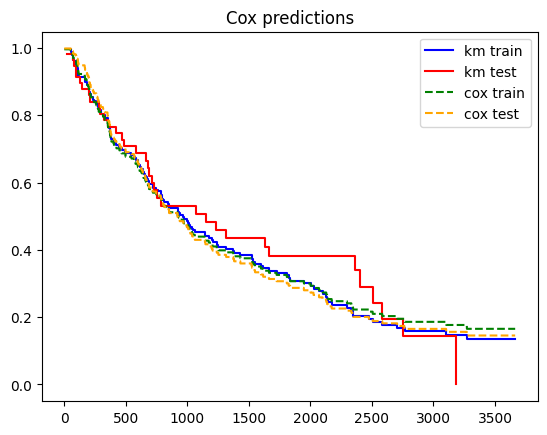

In [ ]:
#Reusing earlier KM code but visualizing by train/test split
time, survival_prob, conf_int = kaplan_meier_estimator(y_train['event'], y_train['time'], time_enter=None, time_min=None,  
                                                       reverse=False, conf_level=0.95, conf_type="log-log")

plt.step(time, survival_prob, where="post",c="b")

time, survival_prob, conf_int = kaplan_meier_estimator(y_test['event'], y_test['time'], time_enter=None, time_min=None,  
                                                       reverse=False, conf_level=0.95, conf_type="log-log")
plt.step(time, survival_prob, where="post",c="r")



#vanlilla cox plotting along with KM curves
pred_surv_train = cox.predict_survival_function(X_train_sc_e)
pred_surv_test = cox.predict_survival_function(X_test_sc_e)

max_time = int(df['time'].max())
time_points = np.arange(1, max_time + 1)

# Needed claude for this. 
# Documentation code only showed ploting of single observation predictions and was therefore not suited for model evaluation.
mean_surv_train = np.mean([fn(time_points) for fn in pred_surv_train], axis=0)
mean_surv_test = np.mean([fn(time_points) for fn in pred_surv_test], axis=0)

plt.plot(time_points, mean_surv_train, c="g", label="Cox Avg Train", linestyle='--')
plt.plot(time_points, mean_surv_test, c="orange", label="Cox Avg Test", linestyle='--')
plt.title("Cox predictions")
plt.legend(["km train", "km test", "cox train", "cox test"])
plt.show()

Makes sense that cox gets worse at later stages by overestimating risk before the "lifer plateau" due to "linear" assumptions.  
At some level you'd almost want a classifier and 2 separate cox models, one for expected lifers and one for normal members.  
Wonder if that exists?


## Cox coefficent visualization and feature importance for stakeholders

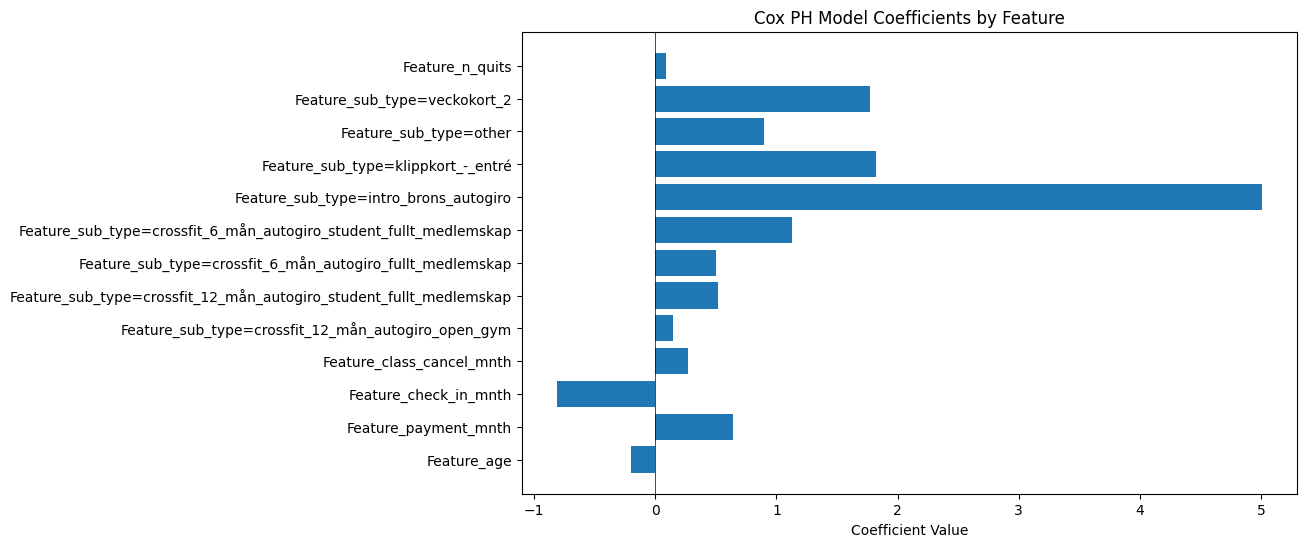

In [ ]:
# Get coefficients for all features 
coefficients = cox.coef_
feature_names = [f"Feature_{i}" for i in X_train_sc_e.columns]  #Get feature names based on columns

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'exp_coefficient': np.exp(coefficients),  # hazard ratios! iirc 0.1 = +10% risk of churning
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

# Too verbose. Barchart is nicer
# print("Feature importance")
# print(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_names, coefficients)
plt.xlabel('Coefficient Value')
plt.title('Cox PH Model Coefficients by Feature')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.show()

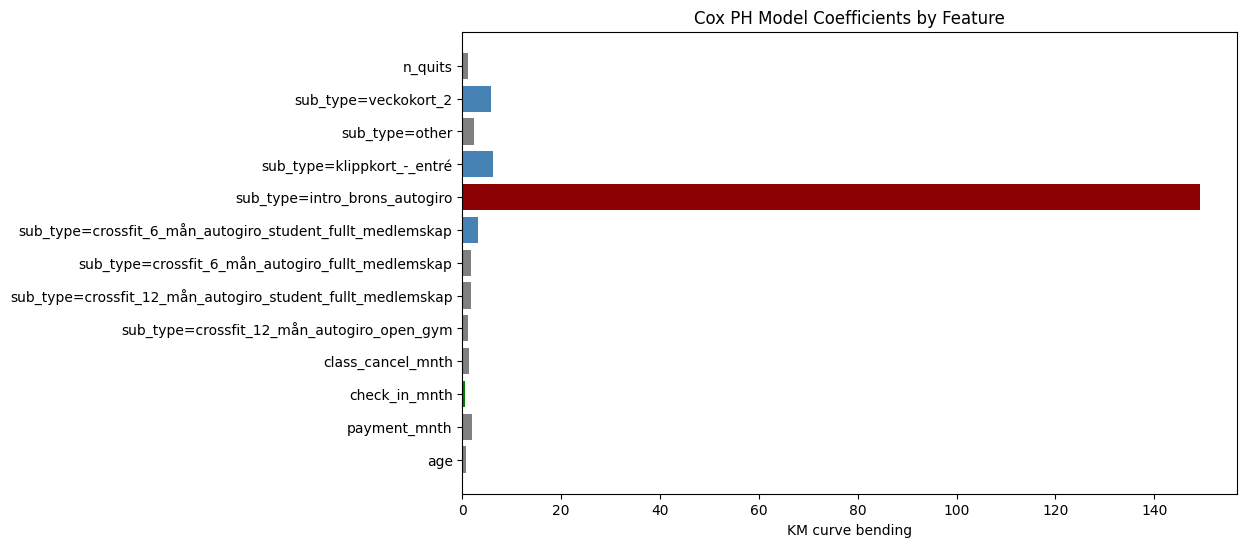

In [ ]:
# Get coefficients for all features 
coefficients = cox.coef_
feature_names = [f"{i}" for i in X_train_sc_e.columns]  #Get feature names based on columns

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'exp_coefficient': np.exp(coefficients),  # hazard ratios! iirc 0.1 = +10% risk of churning
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

plt.figure(figsize=(10, 6))

colors = ["darkred" if c > 2 else "steelblue" for c in coefficients]

colors2 = []
for c in coefficients:
    if c > 2:
        colors2.append("darkred")
    elif 2 > c > 1:
        colors2.append("steelblue")
    elif c<-0.5:
        colors2.append("green")
    else:
        colors2.append("grey")


plt.barh(feature_names, np.exp(coefficients), color=colors2)


plt.xlabel('KM curve bending')
plt.title('Cox PH Model Coefficients by Feature')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
# ticks = np.arange(np.floor(np.min(coefficients)), np.max(coefficients) + 1, step=1)
# plt.xticks(ticks, labels=np.round(np.exp(ticks), 2))

ticks = np.arange(np.floor(np.min(coefficients)), np.max(coefficients) + 1, step=1)

plt.xlabel("KM curve bending")


plt.show()

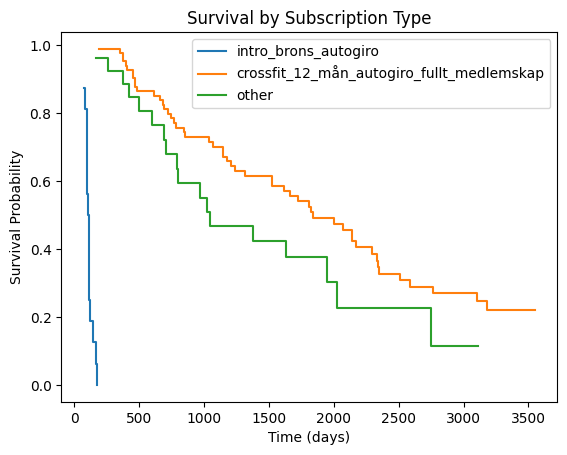

In [ ]:
# KM by subscription type
for sub_type in ['intro_brons_autogiro', 'crossfit_12_mån_autogiro_fullt_medlemskap', 'other']:
    mask = df['sub_type'] == sub_type  
    if mask.sum() > 0:  # Only plot if category exists
        time, surv = kaplan_meier_estimator(df[mask]['event'], df[mask]['time'])
        plt.step(time, surv, where='post', label=sub_type)

plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.legend()
plt.title('Survival by Subscription Type')
plt.show()

All intros die!

### Univariate cox visualizations

In [ ]:

# Create a comparison table
univariate_cox_comparison = []

# Univariate results
for col in X_train_sc_e.columns:
    X_train_single = X_train_sc_e[[col]] 
    X_test_single = X_test_sc_e[[col]]
    single_cox = CoxPHSurvivalAnalysis().fit(X_train_single, y_train)
    

    risk_scores_train = single_cox.predict(X_train_single)
    c_single_train = concordance_index_censored(
        y_train['event'], 
        y_train['time'], 
        risk_scores_train
    )[0]

    risk_scores_test = single_cox.predict(X_test_single)
    c_single_test = concordance_index_censored(
        y_test['event'], 
        y_test['time'], 
        risk_scores_test
    )[0]

    univariate_cox_comparison.append({
        'feature': f"{col}",
        'univariate_coef': single_cox.coef_[0],
        'univariate_cindex_train': c_single_train,
        'univariate_cindex_test': c_single_test
    })


univariate_cox_df = pd.DataFrame(univariate_cox_comparison)
univariate_cox_df.round(4)

,feature,univariate_coef,univariate_cindex_train,univariate_cindex_test
0,age,-0.2341,0.5594,0.5050
1,payment_mnth,0.0083,0.4934,0.4397
2,check_in_mnth,-0.5785,0.6261,0.5594
3,class_cancel_mnth,0.1297,0.4728,0.4665
4,sub_type=crossfit_12_mån_autogiro_open_gym,-0.6539,0.5096,0.5000
5,sub_type=crossfit_12_mån_autogiro_student_full...,-0.0571,0.5099,0.5521
6,sub_type=crossfit_6_mån_autogiro_fullt_medlemskap,0.2333,0.5157,0.5050
7,sub_type=crossfit_6_mån_autogiro_student_fullt...,0.3312,0.5054,0.5063
8,sub_type=intro_brons_autogiro,3.8319,0.5722,0.5417
9,sub_type=klippkort_-_entré,1.0165,0.5346,0.5757


No unavailable cox was any good compared to the multivariate.  
They all hover around chance level of prediction except for age and n_quits if you squint.  

## Regularized cox plotting

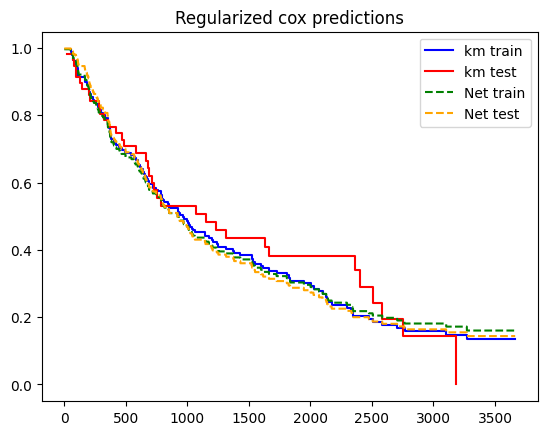

In [ ]:
#Total reuse of first KM/Cox Comparison. Maybe I should have made a function

time, survival_prob, conf_int = kaplan_meier_estimator(y_train['event'], y_train['time'], time_enter=None, time_min=None,  
                                                       reverse=False, conf_level=0.95, conf_type="log-log")

plt.step(time, survival_prob, where="post",c="b")
time, survival_prob, conf_int = kaplan_meier_estimator(y_test['event'], y_test['time'], time_enter=None, time_min=None,  
                                                       reverse=False, conf_level=0.95, conf_type="log-log")
plt.step(time, survival_prob, where="post",c="r")

#Elasticcox
pred_surv_train = best_elasticnet_model.predict_survival_function(X_train_sc_e)
pred_surv_test = best_elasticnet_model.predict_survival_function(X_test_sc_e)


max_time = int(df['time'].max())
time_points = np.arange(1, max_time + 1)

mean_surv_train = np.mean([fn(time_points) for fn in pred_surv_train], axis=0)
mean_surv_test = np.mean([fn(time_points) for fn in pred_surv_test], axis=0)

plt.plot(time_points, mean_surv_train, c="g", label="Net Avg Train", linestyle='--')
plt.plot(time_points, mean_surv_test, c="orange", label="Net Avg Test", linestyle='--')
plt.title("Regularized cox predictions")
plt.legend(["km train", "km test", "Net train", "Net test"])
plt.show()

## Tree plotting

Sadly sklearns .plot_tree didn't work so the best solution was to plot some samples based on risk  
Had some llm help but idea was mine  

/home/carlraask/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SurvivalTree was fitted with feature names
  warnings.warn(


Text(0.5, 1.0, 'Survival Curves by Tree Leaf')

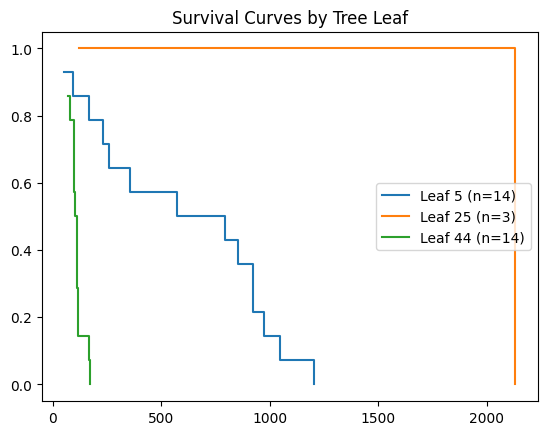

In [ ]:
# Tree sample traversion plotting
leaf_ids = best_tree_model.apply(X_train_sc_e.values.astype(np.float32))

# Pick 3-4 different leaves
unique_leaves = np.unique(leaf_ids)
selected_leaves = unique_leaves[[0, len(unique_leaves)//2, -1]]  # First, middle, last

# Plot K-M curve for members in each leaf
for leaf in selected_leaves:
    mask = leaf_ids == leaf
    leaf_members = y_train[mask]
    
    time, surv, conf = kaplan_meier_estimator(
        leaf_members['event'], 
        leaf_members['time'],
        conf_type="log-log"
    )
    
    plt.step(time, surv, where='post', label=f'Leaf {leaf} (n={mask.sum()})')

plt.legend()
plt.title('Survival Curves by Tree Leaf')

## Forest plotting

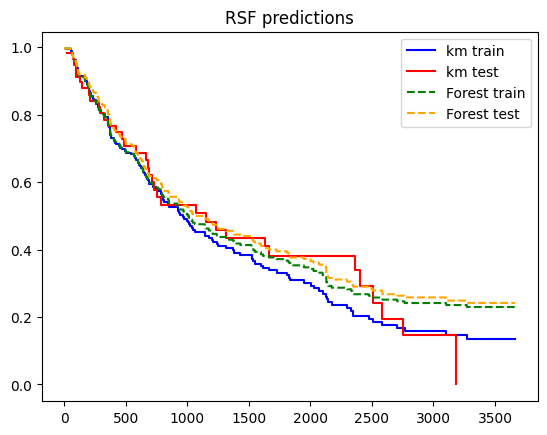

In [ ]:
#Total reuse of first KM/Cox Comparison. Deffo should have made a function
time, survival_prob, conf_int = kaplan_meier_estimator(y_train['event'], y_train['time'], time_enter=None, time_min=None,  
                                                       reverse=False, conf_level=0.95, conf_type="log-log")

plt.step(time, survival_prob, where="post",c="b")
time, survival_prob, conf_int = kaplan_meier_estimator(y_test['event'], y_test['time'], time_enter=None, time_min=None,  
                                                       reverse=False, conf_level=0.95, conf_type="log-log")
plt.step(time, survival_prob, where="post",c="r")

#Forest
pred_surv_train = best_forest_model.predict_survival_function(X_train_sc_e)
pred_surv_test = best_forest_model.predict_survival_function(X_test_sc_e)


max_time = int(df['time'].max())
time_points = np.arange(1, max_time + 1)

mean_surv_train = np.mean([fn(time_points) for fn in pred_surv_train], axis=0)
mean_surv_test = np.mean([fn(time_points) for fn in pred_surv_test], axis=0)

plt.plot(time_points, mean_surv_train, c="g", label="Forest Avg Train", linestyle='--')
plt.plot(time_points, mean_surv_test, c="orange", label="Forest Avg Test", linestyle='--')
plt.title("RSF predictions")
plt.legend(["km train", "km test", "Forest train", "Forest test"])
plt.show()


# Priority members

Step 1: Check wether there are any current introductory members 

In [ ]:
# Identify current at-risk members for intervention
df_high_risk = df[(df['event'] == False) & (df['sub_type'] == 'intro_brons_autogiro')]
df_high_risk

,anon_id,birth_y_m,age,most_recent_visit,membership_creation,most_recent_y,most_recent_m,most_recent_d,check_in,tot_class_cancellations,total_ltv_inc,total_ltv_ex,days_since_last_pay,sub_type,subscription_duration_days,theoretical_inactive_date,sub_cancellation_date,n_quits,active,event,time,days_since_last_visit,class_cancel_mnth,payment_mnth,check_in_mnth


Found nothing. Double checking below.

In [ ]:
df[df['sub_type'] == 'intro_brons_autogiro']["event"].value_counts()

event
True    16
Name: count, dtype: int64

No active intro members currently

In [ ]:
# Filter df_train for active members
active_train = df_train[df_train['event'] == False].copy()

# Get their processed features (already in X_train_sc_e)
active_indices = active_train.index
X_active_train = X_train_sc_e.loc[active_indices]

# Get risk scores from best model
active_train['risk_score'] = best_forest_model.predict(X_active_train)

# Top n highest risk
high_risk_list_train = active_train.nlargest(15, 'risk_score')[
    ['anon_id', 'sub_type', 'time', 'check_in_mnth', 'risk_score']
]
high_risk_list_train.head()

,anon_id,sub_type,time,check_in_mnth,risk_score
301,c729edc9-1c46-4446-bc11-df0ff2fde8de,crossfit_6_mån_autogiro_fullt_medlemskap,30,1.0,159.062281
295,c26c8d9a-e4fc-4ebb-863d-7305c91a2297,crossfit_12_mån_autogiro_student_fullt_medlemskap,72,2.916667,132.650118
236,bc4fd424-00ae-435c-881e-be904592e841,crossfit_12_mån_autogiro_fullt_medlemskap,653,2.02144,129.234971
265,63051bc8-cfbc-43a0-a3bd-59b71b64c960,klippkort_-_entré,360,1.583333,111.241761
262,4a3f5eb7-dde4-4ddb-9625-19df4a6b77d6,crossfit_12_mån_autogiro_fullt_medlemskap,394,1.446701,105.528017


In [ ]:
# Filter df_test for active members
active_test = df_test[df_test['event'] == False].copy()

# Get their processed features
active_indices = active_test.index
X_active_test = X_test_sc_e.loc[active_indices]

# Get risk scores - assign to active_test, not active_members!
active_test['risk_score'] = best_forest_model.predict(X_active_test)

# Top 10 highest risk
high_risk_list_test = active_test.nlargest(10, 'risk_score')[
    ['anon_id', 'sub_type', 'time', 'check_in_mnth', 'risk_score']
]
high_risk_list_test.head()

,anon_id,sub_type,time,check_in_mnth,risk_score
70,039e941d-3c11-451e-90e1-4b592daaf9e3,klippkort_-_entré,2372,0.10118,122.032198
242,7396822c-69f4-40b6-9be9-d65458bfc8d7,crossfit_6_mån_autogiro_fullt_medlemskap,578,0.207612,121.373779
240,9bcb27f4-f77f-4196-a388-a5717d916c73,klippkort_-_entré,599,1.803005,120.231080
256,75c7b539-5180-4f2a-99ea-8ef18c778968,crossfit_6_mån_autogiro_fullt_medlemskap,444,2.77027,109.574122
296,498431df-111e-4578-97e6-07c863806566,crossfit_6_mån_autogiro_fullt_medlemskap,72,2.916667,94.514854


In [ ]:
riskdf=pd.concat([high_risk_list_train, high_risk_list_test])

deanonymization_df=riskdf[["anon_id", "risk_score"]] #just need anon id and risk score for joining to original names
deanonymization_df.to_csv("deanonymization_df.csv",index=False)

Delivered to deaonon code!

But I figure I should make some visualizations as well to go along with the df table

In [ ]:

#need this df for prediction as its scaled and OHEd
all_active_X=pd.concat([X_active_train,X_active_test])

#This merged df has anon id and prior risk scores
all_active_with_risk = pd.concat([active_train, active_test])



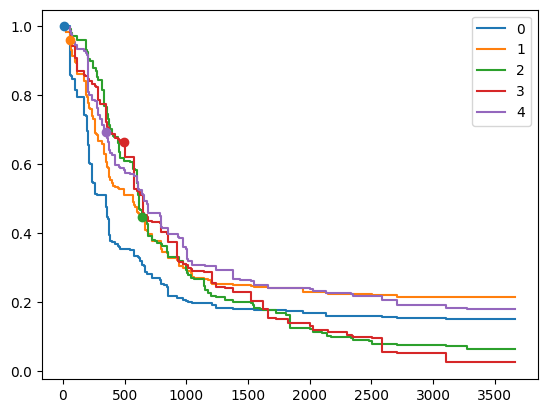

In [ ]:

#grabbing top n risky members
top5 = all_active_with_risk.nlargest(5, 'risk_score')
top5_for_modelling = all_active_X.loc[top5.index]
top5_ids = top5['anon_id'].values

survs_fns = best_forest_model.predict_survival_function(top5_for_modelling)

#I needed claude for this one
for idx, fn in enumerate(survs_fns):
    plt.step(fn.x, fn(fn.x), where="post", label=idx)
    t = top5["subscription_duration_days"].iloc[idx]
    y = fn(t)
    plt.scatter(t, y, zorder=5)

plt.legend()
plt.show()

This looks weird. (see report)  
Trying to filter new members as their monthly aggregated results will be artificially deflated due to not having been members for a month yet

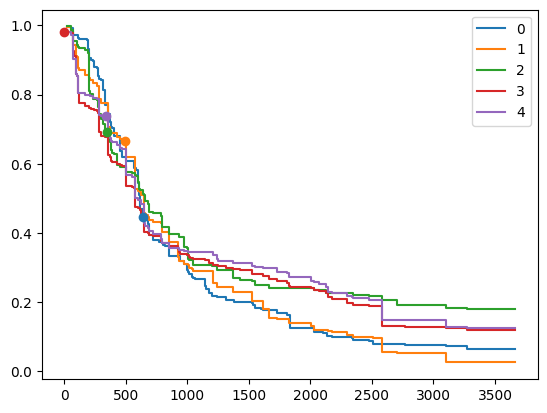

In [ ]:
all_active_with_risk_ltm=all_active_with_risk[all_active_with_risk["time"]>90]


#grabbing top n risky members
top5 = all_active_with_risk_ltm.nlargest(5, 'risk_score')
top5_for_modelling = all_active_X.loc[top5.index]
top5_ids = top5['anon_id'].values

survs_fns = best_forest_model.predict_survival_function(top5_for_modelling)

#I needed claude for this one
for idx, fn in enumerate(survs_fns):
    plt.step(fn.x, fn(fn.x), where="post", label=idx)
    t = top5["subscription_duration_days"].iloc[idx]
    y = fn(t)
    plt.scatter(t, y, zorder=5)

plt.legend()
plt.show()

This looks a bit better!
Idx 3 looks interesting

In [ ]:
all_active_with_risk_ltm.nlargest(5, 'risk_score').iloc[3]

anon_id                       9bcb27f4-f77f-4196-a388-a5717d916c73
birth_y_m                                      1984-04-01 00:00:00
age                                                             42
most_recent_visit                              2026-02-05 16:03:00
membership_creation                            2024-06-25 00:00:00
most_recent_y                                                 2026
most_recent_m                                                    2
most_recent_d                                                    5
check_in                                                        36
tot_class_cancellations                                        145
total_ltv_inc                                                150.0
total_ltv_ex                                                141.51
days_since_last_pay                                            487
sub_type                                         klippkort_-_entré
subscription_duration_days                                    

This one have an more cancellations than checkins across their lifetime and 9 days since last visit.  
~2 year membership starting with a 12mnth lockin period.  
Domain knowledge says this looks like someone not quite getting their training value based on the gyms pricing.  
And pretty much hitting 0.5 on prediction curve.  
Clearly someone to keep an eye on and see if a small intervention can increase training frequency!

Sucess! For small business with small dataset. Need individual assessment on each member here

# Fnal export!

In [ ]:
deanonymization_ltm_df=all_active_with_risk_ltm[["anon_id", "risk_score",'age', 'most_recent_visit', 'time',
       'days_since_last_visit', 'class_cancel_mnth', 'payment_mnth','sub_type',
       'check_in_mnth']] #Realized it was better to move behavioural features along for communication
deanonymization_ltm_df.to_csv("deanonymization_ltm_df.csv",index=False)



In [ ]:
# lt_test=pd.read_csv("deanonymization_ltm_df.csv")
# lt_test.head()